# Week 5 — Shallow Neural Network Classifier

## Objective

This notebook extends the Week 3 CSP+LDA and Week 4 classical machine-learning benchmarks by implementing a shallow feedforward neural network in PyTorch for robot sensor mode classification.

The main objectives are to:

1. Train a shallow neural network using the same PATROL vs. FAULT classification task and 80/20 train-test split used in Week 3.
2. Evaluate training loss and validation accuracy across epochs.
3. Perform a small hyperparameter sensitivity analysis over hidden-layer size, dropout rate, and learning rate.
4. Evaluate the best neural-network configuration using accuracy, precision, recall, and F1 score.
5. Compare the neural network with the Week 3 CSP+LDA model and the best Week 4 classical classifier.
6. Use repeated seeded runs and a paired t-test to determine whether differences between the top-performing methods are statistically significant.
7. Assess whether any improvement from the neural network justifies its additional complexity for edge deployment.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import ttest_rel

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

PyTorch version: 2.13.0
NumPy version: 2.4.6
Pandas version: 3.0.5


In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

Random seed: 42
Device: cpu


## 1. Data Loading and Week 3-Compatible Preprocessing

To maintain a fair comparison with the Week 3 CSP+LDA benchmark, this notebook uses the same high-frequency robot sensor dataset and PATROL vs. FAULT classification task.

The high-frequency sensor stream is segmented into 30-second windows at a sampling rate of 20 Hz, corresponding to 600 samples per window.

The same sensor channels used in the Week 3 pipeline are retained:

- motor current
- x-axis acceleration
- y-axis acceleration
- z-axis acceleration
- IMU magnitude

The train-test split is reproduced using an 80/20 stratified split with random state 42.

In [3]:
DATA_PATH = "../data/robot_sensor_highfreq.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (48000, 8)


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nMode distribution:")
print(df["mode"].value_counts())

Columns:
['time', 'mode', 'motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude', 'window_id']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           48000 non-null  float64
 1   mode           48000 non-null  str    
 2   motor_current  48000 non-null  float64
 3   accel_x        48000 non-null  float64
 4   accel_y        48000 non-null  float64
 5   accel_z        48000 non-null  float64
 6   imu_magnitude  48000 non-null  float64
 7   window_id      48000 non-null  int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 2.9 MB

Mode distribution:
mode
PATROL      12000
ALERT       12000
CHARGING    12000
FAULT       12000
Name: count, dtype: int64


In [5]:
# Keep the same binary classification task as Week 3
binary_df = df[df["mode"].isin(["PATROL", "FAULT"])].copy()

SENSOR_COLS = [
    "motor_current",
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude"
]

print("Binary dataset shape:", binary_df.shape)
print("\nMode distribution:")
print(binary_df["mode"].value_counts())

print("\nNumber of unique windows:")
print(binary_df["window_id"].nunique())

Binary dataset shape: (24000, 8)

Mode distribution:
mode
PATROL    12000
FAULT     12000
Name: count, dtype: int64

Number of unique windows:
20


### Window-Level Feature Representation

The high-frequency dataset contains multiple sensor samples within each 30-second operational window. To construct fixed-length inputs for a feedforward neural network, each window is represented using summary statistics from the five sensor channels.

For every sensor channel, the following statistics are extracted:

- mean
- standard deviation
- minimum
- maximum
- root mean square (RMS)

With five sensor channels and five statistics per channel, each 30-second window is represented by a 25-dimensional feature vector.

This preserves the same window-level classification structure used in the Week 3 benchmark while providing fixed-dimensional inputs suitable for a shallow feedforward neural network.

In [11]:
def rms(x):
    return np.sqrt(np.mean(np.square(x)))


feature_rows = []

# Group by BOTH mode and window_id because window_id is reused across modes
for (mode, window_id), group in binary_df.groupby(["mode", "window_id"]):
    
    row = {
        "window_id": window_id,
        "mode": mode
    }
    
    for col in SENSOR_COLS:
        values = group[col].values
        
        row[f"{col}_mean"] = np.mean(values)
        row[f"{col}_std"] = np.std(values)
        row[f"{col}_min"] = np.min(values)
        row[f"{col}_max"] = np.max(values)
        row[f"{col}_rms"] = rms(values)
    
    feature_rows.append(row)


features_df = pd.DataFrame(feature_rows)

print("Window-level dataset shape:", features_df.shape)

print("\nClass distribution:")
print(features_df["mode"].value_counts())

print("\nWindows per mode:")
print(features_df.groupby("mode")["window_id"].nunique())

display(features_df.head())

Window-level dataset shape: (40, 27)

Class distribution:
mode
FAULT     20
PATROL    20
Name: count, dtype: int64

Windows per mode:
mode
FAULT     20
PATROL    20
Name: window_id, dtype: int64


,window_id,mode,motor_current_mean,motor_current_std,motor_current_min,motor_current_max,motor_current_rms,accel_x_mean,accel_x_std,accel_x_min,...,accel_z_mean,accel_z_std,accel_z_min,accel_z_max,accel_z_rms,imu_magnitude_mean,imu_magnitude_std,imu_magnitude_min,imu_magnitude_max,imu_magnitude_rms
0,0,FAULT,4.495119,0.813599,2.578136,6.394661,4.568155,-0.009571,0.569594,-1.396704,...,9.816839,0.468487,8.761679,10.832680,9.828012,9.846246,0.467205,8.767102,10.878254,9.857324
1,1,FAULT,4.491595,0.808504,2.262720,6.697801,4.563782,0.006715,0.561202,-1.512459,...,9.820204,0.482237,8.579672,10.813154,9.832037,9.849401,0.480818,8.580255,10.818737,9.861130
2,2,FAULT,4.527494,0.815935,2.577956,6.807228,4.600429,0.008193,0.564069,-1.372750,...,9.814896,0.471608,8.718393,10.851637,9.826220,9.843582,0.470592,8.738981,10.858304,9.854825
3,3,FAULT,4.499728,0.814164,2.549332,6.371952,4.572791,0.009484,0.572236,-1.304555,...,9.798395,0.467616,8.765072,10.933663,9.809547,9.828003,0.467085,8.823486,10.959201,9.839096
4,4,FAULT,4.519681,0.807101,2.520722,6.793703,4.591179,-0.000083,0.572550,-1.392858,...,9.812317,0.462997,8.681198,10.809768,9.823234,9.842404,0.461821,8.698998,10.849405,9.853232


In [12]:
feature_cols = [
    col for col in features_df.columns
    if col not in ["window_id", "mode"]
]

X = features_df[feature_cols].values.astype(np.float32)

# Binary labels: PATROL = 0, FAULT = 1
y = (features_df["mode"] == "FAULT").astype(np.int64).values

# Globally unique window identifier
window_keys = (
    features_df["mode"].astype(str)
    + "_"
    + features_df["window_id"].astype(str)
).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(feature_cols))

print("\nClass counts:")
print("PATROL:", np.sum(y == 0))
print("FAULT :", np.sum(y == 1))

X shape: (40, 25)
y shape: (40,)
Number of features: 25

Class counts:
PATROL: 20
FAULT : 20


In [13]:
X_train_full, X_test, y_train_full, y_test, key_train_full, key_test = train_test_split(
    X,
    y,
    window_keys,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Full training set:", X_train_full.shape)
print("Held-out test set:", X_test.shape)

print("\nTraining class counts:")
print("PATROL:", np.sum(y_train_full == 0))
print("FAULT :", np.sum(y_train_full == 1))

print("\nTest class counts:")
print("PATROL:", np.sum(y_test == 0))
print("FAULT :", np.sum(y_test == 1))

print("\nHeld-out test windows:")
print(key_test)

Full training set: (32, 25)
Held-out test set: (8, 25)

Training class counts:
PATROL: 16
FAULT : 16

Test class counts:
PATROL: 4
FAULT : 4

Held-out test windows:
<StringArray>
[ 'PATROL_7', 'PATROL_14',  'FAULT_17',  'FAULT_11',  'PATROL_6',   'FAULT_1',
 'PATROL_10',   'FAULT_0']
Length: 8, dtype: str


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("NN training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Held-out test set:", X_test.shape)

print("\nNN training class counts:")
print("PATROL:", np.sum(y_train == 0))
print("FAULT :", np.sum(y_train == 1))

print("\nValidation class counts:")
print("PATROL:", np.sum(y_val == 0))
print("FAULT :", np.sum(y_val == 1))

NN training set: (24, 25)
Validation set: (8, 25)
Held-out test set: (8, 25)

NN training class counts:
PATROL: 12
FAULT : 12

Validation class counts:
PATROL: 4
FAULT : 4


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining feature mean after scaling:",
      np.round(X_train_scaled.mean(axis=0)[:5], 3))

print("Training feature std after scaling:",
      np.round(X_train_scaled.std(axis=0)[:5], 3))

Scaled training shape: (24, 25)
Scaled validation shape: (8, 25)
Scaled test shape: (8, 25)

Training feature mean after scaling: [-0. -0.  0.  0. -0.]
Training feature std after scaling: [1. 1. 1. 1. 1.]


## 2. Shallow Neural Network Architecture

A shallow feedforward neural network is implemented in PyTorch to capture nonlinear relationships among the window-level sensor features.

The network contains:

- a 25-dimensional input layer corresponding to the extracted sensor features,
- two hidden fully connected layers,
- batch normalization after each hidden linear transformation,
- ReLU nonlinear activation,
- dropout regularization,
- and a two-unit output layer for PATROL vs. FAULT classification.

The number of hidden units and dropout probability are configurable so that their sensitivity can be evaluated later.

Cross-entropy loss is used as the classification objective.

In [16]:
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units=64, dropout_rate=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_units, hidden_units // 2),
            nn.BatchNorm1d(hidden_units // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_units // 2, 2)
        )

    def forward(self, x):
        return self.network(x)


model = ShallowNN(
    input_dim=X_train_scaled.shape[1],
    hidden_units=64,
    dropout_rate=0.3
).to(device)

print(model)

ShallowNN(
  (network): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [17]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


n_params = count_parameters(model)

print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 4,002


In [18]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 3
Validation batches: 1
Test batches: 1


## 3. Training Procedure

The network is trained using the Adam optimizer and cross-entropy loss. Training performance is monitored using the mean loss across mini-batches, while classification accuracy is evaluated on the validation set after each epoch.

The validation set is derived only from the original Week 3 training partition. The held-out Week 3 test set remains untouched during model training and hyperparameter selection.

The model state achieving the highest validation accuracy is retained for final evaluation.

In [19]:
def train_model(
    model,
    train_loader,
    val_loader,
    learning_rate=1e-3,
    epochs=100
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_accuracies = []

    best_val_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        # ----- Training -----
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # ----- Validation -----
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                predictions = torch.argmax(logits, dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc = correct / total
        val_accuracies.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    model.load_state_dict(best_state)

    return train_losses, val_accuracies, best_val_acc

In [20]:
set_seed(42)

baseline_model = ShallowNN(
    input_dim=X_train_scaled.shape[1],
    hidden_units=64,
    dropout_rate=0.3
).to(device)

train_losses, val_accuracies, best_val_acc = train_model(
    baseline_model,
    train_loader,
    val_loader,
    learning_rate=1e-3,
    epochs=100
)

print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Final training loss: {train_losses[-1]:.4f}")

Best validation accuracy: 1.000
Final training loss: 0.0126


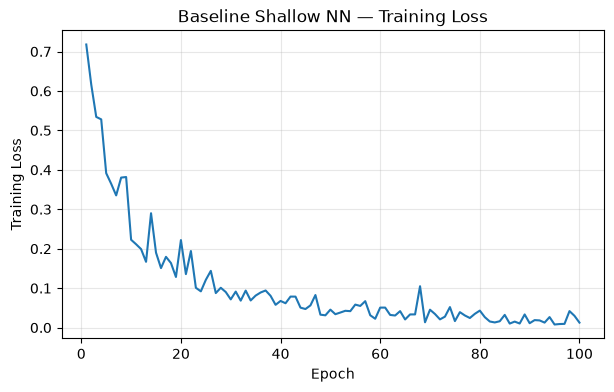

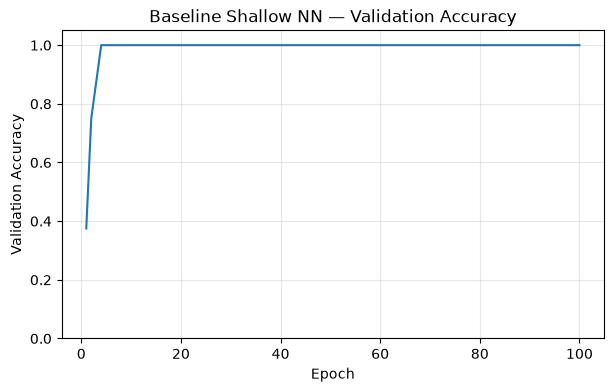

In [21]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Shallow NN — Training Loss")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(epochs_range, val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline Shallow NN — Validation Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()